# Инициализация

Загружаем библиотеки необходимые для выполнения кода ноутбука.

In [10]:
import os

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import boto3
from dotenv import load_dotenv


from sklearn.preprocessing import LabelEncoder
from scipy.sparse import csr_matrix
from implicit.als import AlternatingLeastSquares


import pyarrow as pa
import pyarrow.parquet as pq

load_dotenv()
bucket_name = os.getenv("S3_BUCKET_NAME")

# === ЭТАП 1 ===

# Загрузка первичных данных

Загружаем первичные данные из файлов:
- tracks.parquet
- catalog_names.parquet
- interactions.parquet

In [4]:
DATA_DIR = "data"

tracks = pd.read_parquet(f"{DATA_DIR}/tracks.parquet")
catalog_names = pd.read_parquet(f"{DATA_DIR}/catalog_names.parquet")
interactions = pd.read_parquet(f"{DATA_DIR}/interactions.parquet")

In [5]:
print(f"tracks: {tracks.shape}")
print(f"catalog_names: {catalog_names.shape}")
print(f"interactions: {interactions.shape}")

tracks: (1000000, 4)
catalog_names: (1812471, 3)
interactions: (222629898, 4)


# Обзор данных

Проверяем данные, есть ли с ними явные проблемы.

In [6]:
# просмотр структуры данных

print("tracks")
display(tracks.head())
tracks.info()

print("\ncatalog_names")
display(catalog_names.head())
catalog_names.info()

print("\ninteractions")
display(interactions.head())
interactions.info()

tracks


,track_id,albums,artists,genres
0,26,"[3, 2490753]",[16],"[11, 21]"
1,38,"[3, 2490753]",[16],"[11, 21]"
2,135,"[12, 214, 2490809]",[84],[11]
3,136,"[12, 214, 2490809]",[84],[11]
4,138,"[12, 214, 322, 72275, 72292, 91199, 213505, 24...",[84],[11]


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000000 entries, 0 to 999999
Data columns (total 4 columns):
 #   Column    Non-Null Count    Dtype 
---  ------    --------------    ----- 
 0   track_id  1000000 non-null  int64 
 1   albums    1000000 non-null  object
 2   artists   1000000 non-null  object
 3   genres    1000000 non-null  object
dtypes: int64(1), object(3)
memory usage: 30.5+ MB

catalog_names


,id,type,name
0,3,album,Taller Children
1,12,album,Wild Young Hearts
2,13,album,Lonesome Crow
3,17,album,Graffiti Soul
4,26,album,Blues Six Pack


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1812471 entries, 0 to 1812470
Data columns (total 3 columns):
 #   Column  Dtype 
---  ------  ----- 
 0   id      int64 
 1   type    object
 2   name    object
dtypes: int64(1), object(2)
memory usage: 41.5+ MB

interactions


,user_id,track_id,track_seq,started_at
0,0,99262,1,2022-07-17
1,0,589498,2,2022-07-19
2,0,590262,3,2022-07-21
3,0,590303,4,2022-07-22
4,0,590692,5,2022-07-22


<class 'pandas.core.frame.DataFrame'>
Index: 222629898 entries, 0 to 291
Data columns (total 4 columns):
 #   Column      Dtype         
---  ------      -----         
 0   user_id     int32         
 1   track_id    int32         
 2   track_seq   int16         
 3   started_at  datetime64[ns]
dtypes: datetime64[ns](1), int16(1), int32(2)
memory usage: 5.4 GB


In [7]:
# проверка пропусков

print("tracks")
display(tracks.isna().sum())

print("catalog_names")
display(catalog_names.isna().sum())

print("interactions")
display(interactions.isna().sum())


tracks


track_id    0
albums      0
artists     0
genres      0
dtype: int64

catalog_names


id      0
type    0
name    0
dtype: int64

interactions


user_id       0
track_id      0
track_seq     0
started_at    0
dtype: int64

In [8]:
# Проверяем существующие типы
catalog_names["type"].value_counts()

type
track     1000000
album      658724
artist     153581
genre         166
Name: count, dtype: int64

In [9]:
# идентификаторы объектов из каталога

album_ids = set(
    catalog_names.loc[
        catalog_names["type"] == "album",
        "id"
    ]
)

artist_ids = set(
    catalog_names.loc[
        catalog_names["type"] == "artist",
        "id"
    ]
)

genre_ids = set(
    catalog_names.loc[
        catalog_names["type"] == "genre",
        "id"
    ]
)

In [10]:
# проверка треков на неизвестные альбомы, исполнителей и жанры

unknown_albums = tracks["albums"].map(
    lambda ids: any(item_id not in album_ids for item_id in ids)
)

unknown_artists = tracks["artists"].map(
    lambda ids: any(item_id not in artist_ids for item_id in ids)
)

unknown_genres = tracks["genres"].map(
    lambda ids: any(item_id not in genre_ids for item_id in ids)
)

print(
    "Треков с неизвестными альбомами:",
    unknown_albums.sum()
)

print(
    "Треков с неизвестными исполнителями:",
    unknown_artists.sum()
)

print(
    "Треков с неизвестными жанрами:",
    unknown_genres.sum()
)

Треков с неизвестными альбомами: 0
Треков с неизвестными исполнителями: 0
Треков с неизвестными жанрами: 48345


In [11]:
# поиск неизвестных идентификаторов жанров

unknown_genre_ids = {
    genre_id
    for genres in tracks["genres"]
    for genre_id in genres
    if genre_id not in genre_ids
}

print(f"Количество неизвестных жанров: {len(unknown_genre_ids)}")
print(f"Неизвестные genre_id: {sorted(unknown_genre_ids)}")

Количество неизвестных жанров: 30
Неизвестные genre_id: [124, 126, 130, 131, 132, 133, 134, 135, 146, 148, 150, 151, 152, 153, 154, 155, 156, 157, 158, 159, 160, 161, 162, 163, 164, 165, 166, 167, 168, 169]


In [12]:
# проверим что останутся ли жанры в треках при удалении неизвестных жанров

tracks_with_only_unknown_genres = tracks["genres"].map(
    lambda genres: all(
        genre_id not in genre_ids
        for genre_id in genres
    )
)

print(
    "Треков только с неизвестными жанрами:",
    tracks_with_only_unknown_genres.sum()
)

Треков только с неизвестными жанрами: 3694


In [13]:
# удаление неизвестных жанров из списков genres

tracks["genres"] = tracks["genres"].map(
    lambda genres: [
        genre_id
        for genre_id in genres
        if genre_id in genre_ids
    ]
)

In [14]:
# повторная проверка неизвестных жанров

unknown_genres = tracks["genres"].map(
    lambda ids: any(
        genre_id not in genre_ids
        for genre_id in ids
    )
)

print(
    "Треков с неизвестными жанрами:",
    unknown_genres.sum()
)

print(
    "Треков без жанров:",
    tracks["genres"].map(len).eq(0).sum()
)

Треков с неизвестными жанрами: 0
Треков без жанров: 3694


# Выводы

Приведём выводы по первому знакомству с данными:
- есть ли с данными явные проблемы,
- какие корректирующие действия (в целом) были предприняты.

В ходе первичного анализа данных явных проблем с типами данных и пропусками не обнаружено.

Проверка ссылок на объекты каталога показала, что все идентификаторы альбомов и исполнителей корректны. При этом были обнаружены 30 идентификаторов жанров, отсутствующих в каталоге. Такие идентификаторы встречались у 48 345 треков.

В качестве корректирующего действия неизвестные идентификаторы жанров были удалены из списков `genres`. После обработки у 3 694 треков список жанров остался пустым.

# === ЭТАП 2 ===

# EDA

Распределение количества прослушанных треков.

In [15]:
tracks_per_user = (
    interactions.groupby("user_id")["track_id"]
    .nunique()
)

tracks_per_user.describe()

count    1.373221e+06
mean     1.621224e+02
std      3.512846e+02
min      1.000000e+00
25%      2.300000e+01
50%      5.500000e+01
75%      1.540000e+02
max      1.663700e+04
Name: track_id, dtype: float64

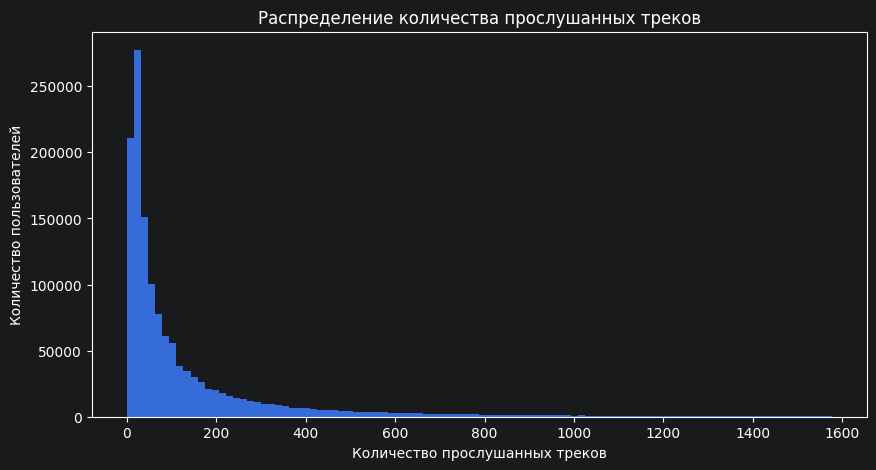

In [16]:
# распределение количества прослушанных треков

upper_bound = tracks_per_user.quantile(0.99)

plt.figure(figsize=(10, 5))

plt.hist(
    tracks_per_user[tracks_per_user <= upper_bound],
    bins=100
)

plt.title("Распределение количества прослушанных треков")
plt.xlabel("Количество прослушанных треков")
plt.ylabel("Количество пользователей")
plt.show()

Наиболее популярные треки

In [17]:
# наиболее популярные треки

track_names = catalog_names[
    catalog_names["type"] == "track"
][["id", "name"]]

popular_tracks = (
    interactions.groupby("track_id")
    .size()
    .reset_index(name="listen_count")
    .sort_values("listen_count", ascending=False)
    .head(20)
    .merge(
        track_names,
        left_on="track_id",
        right_on="id",
        how="left"
    )
    [["track_id", "name", "listen_count"]]
)

popular_tracks

,track_id,name,listen_count
0,53404,Smells Like Teen Spirit,111062
1,33311009,Believer,106921
2,178529,Numb,101924
3,35505245,I Got Love,99490
4,65851540,Юность,86670
5,24692821,Way Down We Go,86246
6,32947997,Shape of You,85886
7,51241318,In The End,85244
8,795836,Shape Of My Heart,85042
9,45499814,Life,84748


Наиболее популярные жанры

In [18]:
# количество прослушиваний каждого трека

track_listens = (
    interactions.groupby("track_id")
    .size()
    .reset_index(name="listen_count")
)

# Присоединяем жанры
tracks_with_listens = tracks[
    ["track_id", "genres"]
].merge(
    track_listens,
    on="track_id",
    how="left"
)

tracks_with_listens["listen_count"] = (
    tracks_with_listens["listen_count"]
    .fillna(0)
    .astype("int64")
)

# Подсчёт суммы прослушиваний
popular_genres = (
    tracks_with_listens
    .explode("genres")
    .groupby("genres")["listen_count"]
    .sum()
    .reset_index()
    .sort_values("listen_count", ascending=False)
    .head(20)
)

# Подтягиваем имена жанров
genre_names = catalog_names[
    catalog_names["type"] == "genre"
][["id", "name"]]

popular_genres = (
    popular_genres
    .merge(
        genre_names,
        left_on="genres",
        right_on="id",
        how="left"
    )
    [["genres", "name", "listen_count"]]
)

popular_genres

,genres,name,listen_count
0,11,pop,55578312
1,75,rap,37799821
2,102,allrock,31092013
3,20,ruspop,26626241
4,3,rusrap,25303695
5,68,electronics,20120981
6,16,dance,16291557
7,2,rusrock,13166147
8,14,rock,12772644
9,47,metal,12437375


Треки, которые никто не прослушал

In [19]:
# треки, которые никто не прослушал

listened_track_ids = set(
    interactions["track_id"].unique()
)

unlistened_tracks = tracks[
    ~tracks["track_id"].isin(listened_track_ids)
]

print(
    "Количество треков без прослушиваний:",
    len(unlistened_tracks)
)

unlistened_tracks.head()

Количество треков без прослушиваний: 0


,track_id,albums,artists,genres


# Преобразование данных

Преобразуем данные в формат, более пригодный для дальнейшего использования в расчётах рекомендаций.

In [20]:

# преобразование данных в формат для дальнейшего расчёта рекомендаций

events = interactions

events.reset_index(
    drop=True,
    inplace=True
)

In [21]:
# Проверка
events.info(memory_usage="deep")

print(type(events.index))

print(
    f"Index memory: "
    f"{events.index.memory_usage(deep=True) / 1024**3:.2f} GB"
)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 222629898 entries, 0 to 222629897
Data columns (total 4 columns):
 #   Column      Dtype         
---  ------      -----         
 0   user_id     int32         
 1   track_id    int32         
 2   track_seq   int16         
 3   started_at  datetime64[ns]
dtypes: datetime64[ns](1), int16(1), int32(2)
memory usage: 3.7 GB
<class 'pandas.core.indexes.range.RangeIndex'>
Index memory: 0.00 GB


# Сохранение данных

Сохраним данные в двух файлах в персональном S3-бакете по пути `recsys/data/`:
- `items.parquet` — все данные о музыкальных треках,
- `events.parquet` — все данные о взаимодействиях.

In [24]:
# сохранение подготовленных данных локально

events.to_parquet(
    "events.parquet",
    index=False
)

tracks.to_parquet(
    "items.parquet",
    index=False
)

In [13]:
# подключение к S3



print("S3 bucket:", os.getenv("S3_BUCKET_NAME"))

s3 = boto3.client(
    "s3",
    endpoint_url="https://storage.yandexcloud.net",
    aws_access_key_id=os.getenv("AWS_ACCESS_KEY_ID"),
    aws_secret_access_key=os.getenv("AWS_SECRET_ACCESS_KEY"),
)



S3 bucket: s3-student-mle-20260525-1c9dbad81c-freetrack


In [32]:
# загрузка подготовленных данных в S3

s3.upload_file(
    "items.parquet",
    bucket_name,
    "recsys/data/items.parquet"
)

s3.upload_file(
    "events.parquet",
    bucket_name,
    "recsys/data/events.parquet"
)

# Очистка памяти

Здесь, может понадобится очистка памяти для высвобождения ресурсов для выполнения кода ниже. 

Приведите соответствующие код, комментарии, например:
- код для удаление более ненужных переменных,
- комментарий, что следует перезапустить kernel, выполнить такие-то начальные секции и продолжить с этапа 3.

In [33]:
# очистка памяти

del interactions
del tracks
del catalog_names
del track_names
del genre_names
del track_listens
del tracks_with_listens
del popular_tracks
del popular_genres
del unlistened_tracks
del tracks_per_user
del unknown_albums
del unknown_artists
del unknown_genres
del album_ids
del artist_ids
del genre_ids
del unknown_genre_ids
del tracks_with_only_unknown_genres

In [34]:
import gc

gc.collect()

6732

In [35]:
events.info(memory_usage="deep")

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 222629898 entries, 0 to 222629897
Data columns (total 4 columns):
 #   Column      Dtype         
---  ------      -----         
 0   user_id     int32         
 1   track_id    int32         
 2   track_seq   int16         
 3   started_at  datetime64[ns]
dtypes: datetime64[ns](1), int16(1), int32(2)
memory usage: 3.7 GB


# === ЭТАП 3 ===

# Загрузка данных

Если необходимо, то загружаем items.parquet, events.parquet.

In [36]:
items = pd.read_parquet(
    "items.parquet"
)

events = pd.read_parquet(
    "events.parquet"
)

In [37]:
print(f"items: {items.shape}")
print(f"events: {events.shape}")

display(items.head())
display(events.head())

items: (1000000, 4)
events: (222629898, 4)


,track_id,albums,artists,genres
0,26,"[3, 2490753]",[16],"[11, 21]"
1,38,"[3, 2490753]",[16],"[11, 21]"
2,135,"[12, 214, 2490809]",[84],[11]
3,136,"[12, 214, 2490809]",[84],[11]
4,138,"[12, 214, 322, 72275, 72292, 91199, 213505, 24...",[84],[11]


,user_id,track_id,track_seq,started_at
0,0,99262,1,2022-07-17
1,0,589498,2,2022-07-19
2,0,590262,3,2022-07-21
3,0,590303,4,2022-07-22
4,0,590692,5,2022-07-22


# Разбиение данных

Разбиваем данные на тренировочную, тестовую выборки.

In [39]:
split_date = pd.Timestamp("2022-12-16")

train = events[
    events["started_at"] < split_date
].copy()

test = events[
    events["started_at"] >= split_date
].copy()

In [40]:
print(
    "Train:",
    train["started_at"].min(),
    "->",
    train["started_at"].max()
)

print(
    "Test:",
    test["started_at"].min(),
    "->",
    test["started_at"].max()
)

print(f"Train shape: {train.shape}")
print(f"Test shape: {test.shape}")

Train: 2022-01-01 00:00:00 -> 2022-12-15 00:00:00
Test: 2022-12-16 00:00:00 -> 2022-12-31 00:00:00
Train shape: (208731252, 4)
Test shape: (13898646, 4)


# Топ популярных

Рассчитаем рекомендации как топ популярных.

In [42]:
TOP_N = 100

top_popular = (
    train.groupby(
        "track_id",
        as_index=False
    )
    .size()
    .rename(
        columns={
            "size": "score"
        }
    )
    .sort_values(
        "score",
        ascending=False
    )
    .head(TOP_N)
    .reset_index(drop=True)
)

top_popular["rank"] = range(
    1,
    len(top_popular) + 1
)

top_popular.head(10)

,track_id,score,rank
0,53404,110026,1
1,33311009,101076,2
2,178529,100866,3
3,35505245,95523,4
4,24692821,84153,5
5,795836,83749,6
6,6705392,80608,7
7,32947997,80243,8
8,37384,79512,9
9,45499814,78564,10


In [43]:
# Сохранение локально
TOP_POPULAR_DIR = "recommendations/top_popular"

os.makedirs(
    TOP_POPULAR_DIR,
    exist_ok=True
)

top_popular.to_parquet(
    f"{TOP_POPULAR_DIR}/top_popular.parquet",
    index=False
)

In [44]:
# Сохранение в s3
s3.upload_file(
    f"{TOP_POPULAR_DIR}/top_popular.parquet",
    bucket_name,
    "recsys/recommendations/top_popular.parquet"
)

# Персональные

Рассчитаем персональные рекомендации.

In [46]:
user_encoder = LabelEncoder()
item_encoder = LabelEncoder()

train["user_idx"] = user_encoder.fit_transform(
    train["user_id"]
)

train["item_idx"] = item_encoder.fit_transform(
    train["track_id"]
)

In [48]:
# Построение user-item матрицы
user_item_matrix = csr_matrix(
    (
        np.ones(
            len(train),
            dtype=np.float32
        ),
        (
            train["user_idx"],
            train["item_idx"]
        )
    ),
    shape=(
        len(user_encoder.classes_),
        len(item_encoder.classes_)
    )
)

print("Матрица:", user_item_matrix.shape)
print("Ненулевых элементов:", user_item_matrix.nnz)

Матрица: (1342566, 999695)
Ненулевых элементов: 208731252


In [51]:
# Обучаем ALS-модель на матрице взаимодействий пользователей и треков


from threadpoolctl import threadpool_limits

model = AlternatingLeastSquares(
    factors=32,
    regularization=0.05,
    alpha=10,
    iterations=15,
    random_state=42,
    calculate_training_loss=True,
)

with threadpool_limits(limits=1, user_api="blas"):
    model.fit(user_item_matrix)

100%|██████████| 15/15 [09:59<00:00, 39.97s/it, loss=0.00104]


In [52]:
# Проверяем работу ALS на одном пользователе и получаем для него 10 рекомендаций

user_idx = 100

item_ids, scores = model.recommend(
    userid=user_idx,
    user_items=user_item_matrix[user_idx],
    N=10,
    filter_already_liked_items=False
)

recommended_track_ids = item_encoder.inverse_transform(
    item_ids
)

pd.DataFrame({
    "track_id": recommended_track_ids,
    "score": scores,
})

,track_id,score
0,65851540,0.349385
1,52380688,0.345990
2,56204557,0.325188
3,62352387,0.320891
4,56920241,0.316786
5,49961817,0.314722
6,54798445,0.311251
7,61565558,0.305009
8,45499814,0.303734
9,57921154,0.303007


In [53]:
# Генерируем персональные ALS-рекомендации для всех пользователей батчами


TOP_N = 100
BATCH_SIZE = 100000

output_dir = "recommendations/personal_als"
output_path = f"{output_dir}/personal_als.parquet"

os.makedirs(
    output_dir,
    exist_ok=True
)

users_for_recommendations = np.arange(
    user_item_matrix.shape[0],
    dtype=np.int32
)

total_users = len(users_for_recommendations)

print(
    f"Пользователей для рекомендаций: "
    f"{total_users:,}"
)

writer = None

try:
    for start in range(
        0,
        total_users,
        BATCH_SIZE
    ):
        end = min(
            start + BATCH_SIZE,
            total_users
        )

        batch_users = users_for_recommendations[
            start:end
        ]

        item_ids_enc, scores = model.recommend(
            userid=batch_users,
            user_items=user_item_matrix[
                batch_users
            ],
            N=TOP_N,
            filter_already_liked_items=False
        )

        batch_size = len(batch_users)

        original_user_ids = (
            user_encoder.classes_[
                batch_users
            ]
        )

        original_track_ids = (
            item_encoder.classes_[
                item_ids_enc.reshape(-1)
            ]
        )

        batch_df = pd.DataFrame({
            "user_id": np.repeat(
                original_user_ids,
                TOP_N
            ),
            "track_id": original_track_ids,
            "score": scores.reshape(-1),
            "rank": np.tile(
                np.arange(
                    1,
                    TOP_N + 1
                ),
                batch_size
            )
        })

        table = pa.Table.from_pandas(
            batch_df,
            preserve_index=False
        )

        if writer is None:
            writer = pq.ParquetWriter(
                output_path,
                table.schema
            )

        writer.write_table(table)

        print(
            f"{end:,} / "
            f"{total_users:,}"
        )

finally:
    if writer is not None:
        writer.close()

Пользователей для рекомендаций: 1,342,566
100,000 / 1,342,566
200,000 / 1,342,566
300,000 / 1,342,566
400,000 / 1,342,566
500,000 / 1,342,566
600,000 / 1,342,566
700,000 / 1,342,566
800,000 / 1,342,566
900,000 / 1,342,566
1,000,000 / 1,342,566
1,100,000 / 1,342,566
1,200,000 / 1,342,566
1,300,000 / 1,342,566
1,342,566 / 1,342,566


In [5]:
# Проверяем сохранённые персональные рекомендации

personal_als = pd.read_parquet(
    output_path
)

print(
    f"personal_als: "
    f"{personal_als.shape}"
)

display(
    personal_als.head(10)
)

personal_als: (99969500, 4)


,track_id,similar_track_id,score,rank
0,26,20111365,0.894730,1
1,26,21644998,0.873237,2
2,26,4850799,0.865434,3
3,26,21846409,0.860117,4
4,26,22836932,0.857655,5
5,26,27419607,0.850662,6
6,26,534679,0.848300,7
7,26,438082,0.839198,8
8,26,107485,0.837781,9
9,26,15673308,0.837153,10


In [55]:
# Загружаем персональные ALS-рекомендации в S3

s3.upload_file(
    output_path,
    bucket_name,
    "recsys/recommendations/personal_als.parquet"
)

# Похожие

Рассчитаем похожие, они позже пригодятся для онлайн-рекомендаций.

In [2]:
# Генерируем похожие треки с помощью обученной ALS-модели и сохраняем батчами

SIMILAR_N = 100
BATCH_SIZE = 100000

output_dir = "recommendations/similar"
output_path = f"{output_dir}/similar.parquet"

In [56]:

os.makedirs(
    output_dir,
    exist_ok=True
)

items_for_similarity = np.arange(
    len(item_encoder.classes_),
    dtype=np.int32
)

total_items = len(items_for_similarity)

print(
    f"Треков для расчёта похожих: "
    f"{total_items:,}"
)

writer = None

try:
    for start in range(
        0,
        total_items,
        BATCH_SIZE
    ):
        end = min(
            start + BATCH_SIZE,
            total_items
        )

        batch_items = items_for_similarity[
            start:end
        ]

        # Запрашиваем SIMILAR_N + 1,
        # потому что первым результатом обычно является сам исходный трек
        similar_ids, scores = model.similar_items(
            batch_items,
            N=SIMILAR_N + 1
        )

        source_ids = []
        target_ids = []
        batch_scores = []
        ranks = []

        for i, source_item_idx in enumerate(
            batch_items
        ):
            row_ids = similar_ids[i]
            row_scores = scores[i]

            # Удаляем исходный трек из собственных рекомендаций
            mask = row_ids != source_item_idx

            row_ids = row_ids[mask][
                :SIMILAR_N
            ]

            row_scores = row_scores[mask][
                :SIMILAR_N
            ]

            count = len(row_ids)

            source_ids.extend(
                [source_item_idx] * count
            )

            target_ids.extend(
                row_ids
            )

            batch_scores.extend(
                row_scores
            )

            ranks.extend(
                range(
                    1,
                    count + 1
                )
            )

        source_ids = np.asarray(
            source_ids,
            dtype=np.int32
        )

        target_ids = np.asarray(
            target_ids,
            dtype=np.int32
        )

        similar_batch = pd.DataFrame({
            "track_id": item_encoder.classes_[
                source_ids
            ],
            "similar_track_id": item_encoder.classes_[
                target_ids
            ],
            "score": np.asarray(
                batch_scores,
                dtype=np.float32
            ),
            "rank": np.asarray(
                ranks,
                dtype=np.int16
            )
        })

        table = pa.Table.from_pandas(
            similar_batch,
            preserve_index=False
        )

        if writer is None:
            writer = pq.ParquetWriter(
                output_path,
                table.schema
            )

        writer.write_table(
            table
        )

        print(
            f"{end:,} / "
            f"{total_items:,}"
        )

finally:
    if writer is not None:
        writer.close()

Треков для расчёта похожих: 999,695
100,000 / 999,695
200,000 / 999,695
300,000 / 999,695
400,000 / 999,695
500,000 / 999,695
600,000 / 999,695
700,000 / 999,695
800,000 / 999,695
900,000 / 999,695
999,695 / 999,695


In [8]:
# Проверяем созданный файл с похожими треками

parquet_file = pq.ParquetFile(
    output_path
)

print(
    "Количество строк:",
    parquet_file.metadata.num_rows
)

print(
    "Количество row groups:",
    parquet_file.metadata.num_row_groups
)

preview = (
    parquet_file
    .read_row_group(0)
    .to_pandas()
    .head(10)
)

preview

Количество строк: 99969500
Количество row groups: 100


,track_id,similar_track_id,score,rank
0,26,20111365,0.894730,1
1,26,21644998,0.873237,2
2,26,4850799,0.865434,3
3,26,21846409,0.860117,4
4,26,22836932,0.857655,5
5,26,27419607,0.850662,6
6,26,534679,0.848300,7
7,26,438082,0.839198,8
8,26,107485,0.837781,9
9,26,15673308,0.837153,10


In [14]:
# Загружаем рекомендации похожих треков в S3

s3.upload_file(
    output_path,
    bucket_name,
    "recsys/recommendations/similar.parquet"
)

# Построение признаков

Построим три признака, можно больше, для ранжирующей модели.

In [15]:
# Формируем признаки для ранжирующей модели:
# ALS score, популярность трека и максимальную похожесть трека.
# Большие parquet-файлы обрабатываем батчами, чтобы снизить потребление RAM.

import gc

FEATURES = [
    "als_score",
    "popular_score",
    "similarity_score",
]

PERSONAL_ALS_PATH = (
    "recommendations/personal_als/"
    "personal_als.parquet"
)

SIMILAR_PATH = (
    "recommendations/similar/"
    "similar.parquet"
)

CANDIDATES_PATH = (
    "recommendations/"
    "candidates_features.parquet"
)

In [17]:
# Загружаем топ популярных треков и подготавливаем признак popular_score

top_popular = pd.read_parquet(
    "recommendations/top_popular/top_popular.parquet"
)

popular_scores = (
    top_popular
    .set_index("track_id")["score"]
    .astype("float32")
)

popular_scores.head()

track_id
53404       110026.0
33311009    101076.0
178529      100866.0
35505245     95523.0
24692821     84153.0
Name: score, dtype: float32

In [18]:
# Рассчитываем максимальный similarity_score для каждого трека,
# работаем с батчами

similarity_scores = {}

similar_file = pq.ParquetFile(
    SIMILAR_PATH
)

for batch in similar_file.iter_batches(
    batch_size=1_000_000,
    columns=[
        "similar_track_id",
        "score",
    ]
):
    batch_df = batch.to_pandas()

    batch_max = (
        batch_df
        .groupby(
            "similar_track_id"
        )["score"]
        .max()
    )

    for track_id, score in batch_max.items():
        current_score = similarity_scores.get(
            track_id
        )

        if (
            current_score is None
            or score > current_score
        ):
            similarity_scores[
                track_id
            ] = score

    del batch_df
    del batch_max

    gc.collect()

print(
    "Треков с similarity_score:",
    len(similarity_scores)
)

Треков с similarity_score: 999467


In [20]:
# Формируем таблицу кандидатов с признаками батчами и сохраняем её в parquet

personal_als_file = pq.ParquetFile(
    PERSONAL_ALS_PATH
)

writer = None

try:
    for batch_number, batch in enumerate(
        personal_als_file.iter_batches(
            batch_size=1_000_000
        ),
        start=1
    ):
        candidates_batch = (
            batch
            .to_pandas()
            .rename(
                columns={
                    "score": "als_score",
                    "rank": "als_rank",
                }
            )
        )

        candidates_batch[
            "popular_score"
        ] = (
            candidates_batch["track_id"]
            .map(popular_scores)
            .fillna(0)
            .astype("float32")
        )

        candidates_batch[
            "similarity_score"
        ] = (
            candidates_batch["track_id"]
            .map(similarity_scores)
            .fillna(0)
            .astype("float32")
        )

        candidates_batch[
            "als_score"
        ] = (
            candidates_batch["als_score"]
            .astype("float32")
        )

        table = pa.Table.from_pandas(
            candidates_batch[
                [
                    "user_id",
                    "track_id",
                    "als_score",
                    "als_rank",
                    "popular_score",
                    "similarity_score",
                ]
            ],
            preserve_index=False
        )

        if writer is None:
            writer = pq.ParquetWriter(
                CANDIDATES_PATH,
                table.schema
            )

        writer.write_table(
            table
        )

        print(
            f"Последний обработанный batch: {batch_number}",
            end="\r"
        )

        del candidates_batch
        del table

        gc.collect()

finally:
    if writer is not None:
        writer.close()

In [21]:
# Проверяем созданную таблицу кандидатов и признаков,

candidates_file = pq.ParquetFile(
    CANDIDATES_PATH
)

print(
    "Количество кандидатов:",
    candidates_file.metadata.num_rows
)

print(
    "Количество row groups:",
    candidates_file.metadata.num_row_groups
)

candidates_preview = (
    candidates_file
    .read_row_group(0)
    .to_pandas()
    .head(10)
)

candidates_preview

Количество кандидатов: 134256600
Количество row groups: 135


,user_id,track_id,als_score,als_rank,popular_score,similarity_score
0,0,597196,0.070913,1,0.0,0.927689
1,0,19972786,0.070438,2,0.0,0.988256
2,0,6006252,0.069134,3,0.0,0.937011
3,0,17856052,0.068309,4,0.0,0.988256
4,0,25903468,0.066484,5,0.0,0.956905
5,0,2173105,0.064067,6,0.0,0.940644
6,0,22434771,0.063257,7,0.0,0.990175
7,0,21101463,0.061813,8,0.0,0.927689
8,0,23915039,0.061147,9,0.0,0.980876
9,0,26800290,0.060856,10,0.0,0.898269


# Ранжирование рекомендаций

Построим ранжирующую модель, чтобы сделать рекомендации более точными. Отранжируем рекомендации.

In [25]:
# Загружаем события для подготовки данных ранжирующей модели

events = pd.read_parquet(
    "events.parquet"
)

# Загружаем события и задаём временные границы для ранжирующей модели
# Разделяем тестовый период на две части:
# 16-23 декабря — для обучения ранжирующей модели,
# 24-31 декабря — для финальной оценки рекомендаций

events = pd.read_parquet(
    "events.parquet"
)

split_date = pd.Timestamp(
    "2022-12-16"
)

ranker_split_date = pd.Timestamp(
    "2022-12-24"
)

ranker_events = events[
    (events["started_at"] >= split_date)
    &
    (events["started_at"] < ranker_split_date)
].copy()

eval_events = events[
    events["started_at"] >= ranker_split_date
].copy()

In [26]:
# Проверяем корректность временного разделения данных

print(
    "Ranker train:",
    ranker_events["started_at"].min(),
    "->",
    ranker_events["started_at"].max()
)

print(
    "Evaluation:",
    eval_events["started_at"].min(),
    "->",
    eval_events["started_at"].max()
)

print(
    "Ranker train shape:",
    ranker_events.shape
)

print(
    "Evaluation shape:",
    eval_events.shape
)

Ranker train: 2022-12-16 00:00:00 -> 2022-12-23 00:00:00
Evaluation: 2022-12-24 00:00:00 -> 2022-12-31 00:00:00
Ranker train shape: (8346176, 4)
Evaluation shape: (5552470, 4)


In [27]:
# Формируем положительные пары user_id + track_id
# по фактическим прослушиваниям в период обучения ranker

positive_pairs = (
    ranker_events[
        [
            "user_id",
            "track_id",
        ]
    ]
    .drop_duplicates()
)

positive_pairs["target"] = 1

print(
    "Положительных пар:",
    len(positive_pairs)
)

Положительных пар: 8346176


In [28]:
# Добавляем target к кандидатам:
# target = 1, если пользователь прослушал трек в период обучения ranker,
# иначе target = 0.
# Обрабатываем кандидатов батчами

CANDIDATES_PATH = (
    "recommendations/"
    "candidates_features.parquet"
)

RANKER_TRAIN_PATH = (
    "recommendations/"
    "ranker_train.parquet"
)

positive_index = pd.MultiIndex.from_frame(
    positive_pairs[
        [
            "user_id",
            "track_id",
        ]
    ]
)

candidates_file = pq.ParquetFile(
    CANDIDATES_PATH
)

writer = None

total_rows = (
    candidates_file
    .metadata
    .num_rows
)

processed_rows = 0

try:
    for batch in candidates_file.iter_batches(
        batch_size=1_000_000
    ):
        ranker_batch = batch.to_pandas()

        batch_index = pd.MultiIndex.from_frame(
            ranker_batch[
                [
                    "user_id",
                    "track_id",
                ]
            ]
        )

        ranker_batch["target"] = (
            batch_index
            .isin(positive_index)
            .astype("int8")
        )

        table = pa.Table.from_pandas(
            ranker_batch,
            preserve_index=False
        )

        if writer is None:
            writer = pq.ParquetWriter(
                RANKER_TRAIN_PATH,
                table.schema
            )

        writer.write_table(
            table
        )

        processed_rows += len(
            ranker_batch
        )

        print(
            f"Обработано: "
            f"{processed_rows:,} / "
            f"{total_rows:,}",
            end="\r"
        )

        del ranker_batch
        del batch_index
        del table

        gc.collect()

finally:
    if writer is not None:
        writer.close()

print()

Обработано: 134,256,600 / 134,256,600


In [29]:
# Проверяем распределение target в данных для обучения ranker

ranker_file = pq.ParquetFile(
    RANKER_TRAIN_PATH
)

positive_count = 0
total_count = 0

for batch in ranker_file.iter_batches(
    batch_size=1_000_000,
    columns=["target"]
):
    target = (
        batch
        .column("target")
        .to_numpy()
    )

    positive_count += target.sum()
    total_count += len(target)

print(
    "Всего кандидатов:",
    f"{total_count:,}"
)

print(
    "Положительных:",
    f"{positive_count:,}"
)

print(
    "Доля положительных:",
    positive_count / total_count
)

Всего кандидатов: 134,256,600
Положительных: 372,449
Доля положительных: 0.0027741578440091588


In [30]:
# Оставляем только пользователей, у которых есть
# одновременно положительные и отрицательные кандидаты

ranker_train = pd.read_parquet(
    RANKER_TRAIN_PATH
)

group_stats = (
    ranker_train
    .groupby("user_id")["target"]
    .agg(
        positives="sum",
        total="count"
    )
)

group_stats["negatives"] = (
    group_stats["total"]
    - group_stats["positives"]
)

valid_users = group_stats[
    (group_stats["positives"] > 0)
    &
    (group_stats["negatives"] > 0)
].index

ranker_train = ranker_train[
    ranker_train["user_id"].isin(
        valid_users
    )
].copy()

In [31]:
# Проверяем итоговую обучающую выборку для ranker

print(
    "Пользователей:",
    ranker_train["user_id"].nunique()
)

print(
    "Строк:",
    len(ranker_train)
)

print(
    "Положительных:",
    ranker_train["target"].sum()
)

print(
    "Доля target=1:",
    ranker_train["target"].mean()
)

Пользователей: 188609
Строк: 18860900
Положительных: 372449
Доля target=1: 0.01974714886352189


In [32]:
# Обучаем ранжирующую модель CatBoost на подготовленных признаках

from catboost import CatBoostRanker

ranker_train = (
    ranker_train
    .sort_values(
        [
            "user_id",
            "als_rank"
        ]
    )
    .reset_index(drop=True)
)

ranker = CatBoostRanker(
    iterations=50,
    depth=6,
    learning_rate=0.05,
    loss_function="YetiRank",
    random_seed=42,
    verbose=10
)

ranker.fit(
    ranker_train[FEATURES],
    ranker_train["target"],
    group_id=ranker_train["user_id"]
)

0:	total: 14.1s	remaining: 11m 31s
10:	total: 2m 30s	remaining: 8m 52s
20:	total: 4m 45s	remaining: 6m 34s
30:	total: 7m 2s	remaining: 4m 18s
40:	total: 9m 17s	remaining: 2m 2s
49:	total: 11m 18s	remaining: 0us


In [33]:
# Сохраняем обученную ранжирующую модель

os.makedirs(
    "models",
    exist_ok=True
)

ranker.save_model(
    "models/catboost_ranker.cbm"
)

In [35]:
# Применяем обученный ranker ко всем кандидатам, используем батчами,
# ранжируем рекомендации внутри каждого пользователя
# и сохраняем итоговый recommendations.parquet

CANDIDATES_PATH = (
    "recommendations/"
    "candidates_features.parquet"
)

RECOMMENDATIONS_PATH = (
    "recommendations/"
    "recommendations.parquet"
)

candidates_file = pq.ParquetFile(
    CANDIDATES_PATH
)

total_rows = (
    candidates_file
    .metadata
    .num_rows
)

processed_rows = 0
writer = None

try:
    for batch in candidates_file.iter_batches(
        batch_size=1_000_000
    ):
        candidates_batch = (
            batch
            .to_pandas()
        )

        # Получаем итоговый score от ranker
        candidates_batch[
            "score"
        ] = (
            ranker.predict(
                candidates_batch[
                    FEATURES
                ]
            )
            .astype("float32")
        )

        # Сортируем рекомендации
        # отдельно для каждого пользователя
        recommendations_batch = (
            candidates_batch[
                [
                    "user_id",
                    "track_id",
                    "score",
                ]
            ]
            .sort_values(
                [
                    "user_id",
                    "score",
                ],
                ascending=[
                    True,
                    False,
                ]
            )
        )

        # Формируем итоговый rank
        recommendations_batch[
            "rank"
        ] = (
            recommendations_batch
            .groupby("user_id")
            .cumcount()
            .add(1)
            .astype("int16")
        )

        table = pa.Table.from_pandas(
            recommendations_batch,
            preserve_index=False
        )

        if writer is None:
            writer = pq.ParquetWriter(
                RECOMMENDATIONS_PATH,
                table.schema
            )

        writer.write_table(
            table
        )

        processed_rows += len(
            candidates_batch
        )

        print(
            f"Обработано: "
            f"{processed_rows:,} / "
            f"{total_rows:,}",
            end="\r"
        )

        del candidates_batch
        del recommendations_batch
        del table

        gc.collect()

finally:
    if writer is not None:
        writer.close()

print()

Обработано: 134,256,600 / 134,256,600


In [36]:
# Проверяем итоговый файл с отранжированными рекомендациями

recommendations_file = pq.ParquetFile(
    RECOMMENDATIONS_PATH
)

print(
    "Количество рекомендаций:",
    recommendations_file.metadata.num_rows
)

print(
    "Количество row groups:",
    recommendations_file.metadata.num_row_groups
)

recommendations_preview = (
    recommendations_file
    .read_row_group(0)
    .to_pandas()
    .head(20)
)

recommendations_preview

Количество рекомендаций: 134256600
Количество row groups: 135


,user_id,track_id,score,rank
0,0,10695539,0.366669,1
1,0,16202171,0.366669,2
2,0,19972786,0.268634,3
3,0,17856052,0.268634,4
4,0,22434771,0.268634,5
5,0,15397485,0.268634,6
6,0,17973078,0.268634,7
7,0,23419375,0.268634,8
8,0,21448396,0.268634,9
9,0,14697223,0.268634,10


In [38]:
# Загружаем итоговые рекомендации в S3

s3.upload_file(
    RECOMMENDATIONS_PATH,
    bucket_name,
    "recsys/recommendations/recommendations.parquet"
)

# Оценка качества

Проверим оценку качества трёх типов рекомендаций: 

- топ популярных,
- персональных, полученных при помощи ALS,
- итоговых
  
по четырем метрикам: recall, precision, coverage, novelty.

In [37]:
# Формируем ground truth по фактическим прослушиваниям
# в финальном периоде оценки 24-31 декабря

ground_truth = (
    eval_events[
        [
            "user_id",
            "track_id",
        ]
    ]
    .drop_duplicates()
    .rename(
        columns={
            "track_id": "item_id"
        }
    )
)

eval_users = (
    ground_truth["user_id"]
    .unique()
)

print(
    "Пользователей для оценки:",
    len(eval_users)
)

print(
    "Положительных пар:",
    len(ground_truth)
)

Пользователей для оценки: 572218
Положительных пар: 5552470


In [39]:
# Загружаем персональные ALS-рекомендации
# только для оценки Top-10

K = 10

personal_als_eval = pd.read_parquet(
    "recommendations/personal_als/personal_als.parquet",
    columns=[
        "user_id",
        "track_id",
        "rank",
    ],
    filters=[
        ("rank", "<=", K)
    ]
)

personal_als_eval = (
    personal_als_eval[
        personal_als_eval["user_id"].isin(
            eval_users
        )
    ]
    .rename(
        columns={
            "track_id": "item_id"
        }
    )
)

print(
    "ALS recommendations:",
    personal_als_eval.shape
)

ALS recommendations: (5418370, 3)


In [40]:
# Загружаем итоговые рекомендации ranker
# только для оценки Top-10

final_eval = pd.read_parquet(
    "recommendations/recommendations.parquet",
    columns=[
        "user_id",
        "track_id",
        "rank",
    ],
    filters=[
        ("rank", "<=", K)
    ]
)

final_eval = (
    final_eval[
        final_eval["user_id"].isin(
            eval_users
        )
    ]
    .rename(
        columns={
            "track_id": "item_id"
        }
    )
)

print(
    "Final recommendations:",
    final_eval.shape
)

Final recommendations: (5418370, 3)


In [41]:
# Формируем Top Popular рекомендации для всех пользователей
# из финальной выборки

top_popular = pd.read_parquet(
    "recommendations/top_popular/top_popular.parquet"
)

popular_items = (
    top_popular[
        top_popular["rank"] <= K
    ]["track_id"]
    .to_numpy()
)

top_popular_eval = pd.DataFrame({
    "user_id": np.repeat(
        eval_users,
        len(popular_items)
    ),
    "item_id": np.tile(
        popular_items,
        len(eval_users)
    ),
    "rank": np.tile(
        np.arange(
            1,
            len(popular_items) + 1
        ),
        len(eval_users)
    )
})

print(
    "Top Popular recommendations:",
    top_popular_eval.shape
)

Top Popular recommendations: (5722180, 3)


In [42]:
# Рассчитываем novelty на основе популярности треков
# только в тренировочном периоде до 16 декабря

events_train = pd.read_parquet(
    "events.parquet",
    columns=[
        "track_id",
        "started_at",
    ]
)

events_train = events_train[
    events_train["started_at"]
    < pd.Timestamp("2022-12-16")
]

item_counts = (
    events_train["track_id"]
    .value_counts()
)

total_interactions = len(
    events_train
)

novelty_map = -np.log2(
    item_counts
    / total_interactions
)

del events_train
del item_counts

gc.collect()

1675

In [43]:
# Определяем размер каталога для расчёта coverage

catalog = pd.read_parquet(
    "items.parquet",
    columns=[
        "track_id"
    ]
)

catalog_size = (
    catalog["track_id"]
    .nunique()
)

print(
    "Размер каталога:",
    catalog_size
)

del catalog

gc.collect()

Размер каталога: 1000000


0

In [44]:
# Рассчитываем precision, recall, coverage и novelty
# для заданного набора рекомендаций

def evaluate_recommendations(
    recommendations_df,
    ground_truth,
    catalog_size,
    novelty_map,
    k=10
):
    recs = (
        recommendations_df[
            recommendations_df["rank"] <= k
        ][
            [
                "user_id",
                "item_id",
            ]
        ]
        .drop_duplicates()
        .copy()
    )

    truth = (
        ground_truth[
            [
                "user_id",
                "item_id",
            ]
        ]
        .drop_duplicates()
        .copy()
    )

    relevant_count = (
        truth
        .groupby("user_id")
        .size()
    )

    hits = recs.merge(
        truth.assign(
            hit=1
        ),
        on=[
            "user_id",
            "item_id",
        ],
        how="left"
    )

    hits["hit"] = (
        hits["hit"]
        .fillna(0)
        .astype("int8")
    )

    hits_per_user = (
        hits
        .groupby("user_id")["hit"]
        .sum()
        .reindex(
            relevant_count.index,
            fill_value=0
        )
    )

    precision = (
        hits_per_user
        / k
    ).mean()

    recall = (
        hits_per_user
        / relevant_count
    ).mean()

    coverage = (
        recs["item_id"]
        .nunique()
        / catalog_size
    )

    novelty = (
        recs["item_id"]
        .map(
            novelty_map
        )
        .dropna()
        .mean()
    )

    return {
        "precision": precision,
        "recall": recall,
        "coverage": coverage,
        "novelty": novelty,
    }

In [45]:
# Рассчитываем метрики для Top Popular, ALS и Final Ranker

metrics_top_popular = evaluate_recommendations(
    top_popular_eval,
    ground_truth,
    catalog_size,
    novelty_map,
    k=K
)

metrics_als = evaluate_recommendations(
    personal_als_eval,
    ground_truth,
    catalog_size,
    novelty_map,
    k=K
)

metrics_final = evaluate_recommendations(
    final_eval,
    ground_truth,
    catalog_size,
    novelty_map,
    k=K
)

In [46]:
# Выводим итоговое сравнение качества рекомендаций

metrics = pd.DataFrame([
    {
        "model": "Top Popular",
        **metrics_top_popular
    },
    {
        "model": "ALS",
        **metrics_als
    },
    {
        "model": "Final Ranker",
        **metrics_final
    },
]).set_index(
    "model"
)

display(
    metrics.style.format({
        "precision": "{:.6f}",
        "recall": "{:.6f}",
        "coverage": "{:.6f}",
        "novelty": "{:.4f}",
    })
)

,precision,recall,coverage,novelty
model,,,,
Top Popular,0.001884,0.002604,0.000010,11.1987
ALS,0.002252,0.008456,0.007882,12.5467
Final Ranker,0.004685,0.013850,0.006056,13.0924


# === Выводы, метрики ===

Основные выводы при работе над расчётом рекомендаций, рассчитанные метрики.

В рамках проекта были подготовлены данные о треках и взаимодействиях пользователей, проведён EDA, построены базовые и персональные рекомендации, а также обучена ранжирующая модель.

Для оценки качества использовались метрики `precision@10`, `recall@10`, `coverage` и `novelty`.

Получены следующие результаты:

| Модель | Precision@10 | Recall@10 | Coverage | Novelty |
|---|---:|---:|---:|---:|
| Top Popular | 0.001884 | 0.002604 | 0.000010 | 11.1987 |
| ALS | 0.002252 | 0.008456 | 0.007882 | 12.5467 |
| Final Ranker | 0.004685 | 0.013850 | 0.006056 | 13.0924 |

Неперсонализированный подход Top Popular показал самые низкие значения precision и recall, а также минимальное покрытие каталога.

Персональные рекомендации ALS улучшили recall и значительно увеличили coverage по сравнению с Top Popular. Это показывает преимущество персонализированного подхода перед рекомендацией одинакового набора популярных треков всем пользователям.

Лучшие значения `precision@10` и `recall@10` показала итоговая ранжирующая модель. По сравнению с ALS precision увеличился примерно в 2 раза, а recall — примерно в 1,6 раза. Также увеличилась novelty рекомендаций, то есть итоговая модель чаще предлагает менее популярные треки.

При этом coverage Final Ranker ниже, чем у ALS (`0.006056` против `0.007882`). Это означает, что улучшение точности ранжирования сопровождается некоторым уменьшением разнообразия рекомендованных треков.

Таким образом, использование ALS для генерации персональных кандидатов и последующего ранжирования с помощью обученной модели позволило получить лучшие итоговые рекомендации по основным метрикам precision, recall и novelty.